<a href="https://colab.research.google.com/github/yulivvv/bge-m3-quantized-/blob/main/bge_m3_quantized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Стандартное домашнее задание: Квантизация энкодерной модели для семантического поиска

В рамках этого домашнего задания вы пройдете процесс оптимизации инференса предобученной многоязычной энкодерной модели `BAAI/bge-m3` для работы с русскоязычными текстами. Ваша цель - применить динамическую квантизацию к модели и замерить, как это повлияло на качество семантического поиска, скорость работы и размер модели в памяти.

**Важное предупреждение:** Квантизация это процесс сжатия больших языковых моделей (LLM) путем уменьшения объема памяти для хранения их параметров. Она меняет числа высокой точности на числа меньшей точности (например, с 16 бит до 8 или 4 бит). Это позволяет ускорить инференс на CPU и уменьшить размер модели, но может привести к незначительной потере качества (деградации метрик). В рамках выполнения данного ДЗ в образовательных целях мы замерим этот компромисс.

In [1]:
!pip install sentence-transformers datasets faiss-cpu umap-learn matplotlib seaborn pandas numpy

In [2]:
import os
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import umap
from tqdm.auto import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Часть 1. Визуализация пространства эмбеддингов базовой модели (20 баллов)

Сначала визуализируем эмбеддинги коротких текстов, чтобы увидеть, насколько хорошо базовая модель разделяет их по смыслу.

**Задание:**
1. Загрузите датасет `ai-forever/headline-classification` (сплит `test`, возьмите первые 1000 примеров: `split="test[:1000]"`). Датасет содержит колонки `text` (заголовок новости на русском языке, строка), `label` (номер класса, число) и `label_text` (название тематики, строка: спорт, политика, экономика и т.д.). Для получения эмбеддингов используйте колонку `text`, для раскраски точек на графике - колонку `label_text`.
2. Инициализируйте базовую модель `BAAI/bge-m3` с помощью библиотеки `sentence-transformers`.
3. Получите эмбеддинги для текстов из датасета.
4. Напишите функцию для понижения размерности эмбеддингов до 2D с использованием алгоритма UMAP.
5. Постройте scatter plot, раскрасив точки в соответствии с метками классов.

**Подсказки и рекомендации:**
* Обязательно зафиксируйте `random_state` в UMAP для воспроизводимости.
* `bge-m3` - довольно крупная модель. При получении эмбеддингов используйте параметр `batch_size` (например, 32 или 64), чтобы не перегрузить память.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/36000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/12000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12000 [00:00<?, ? examples/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


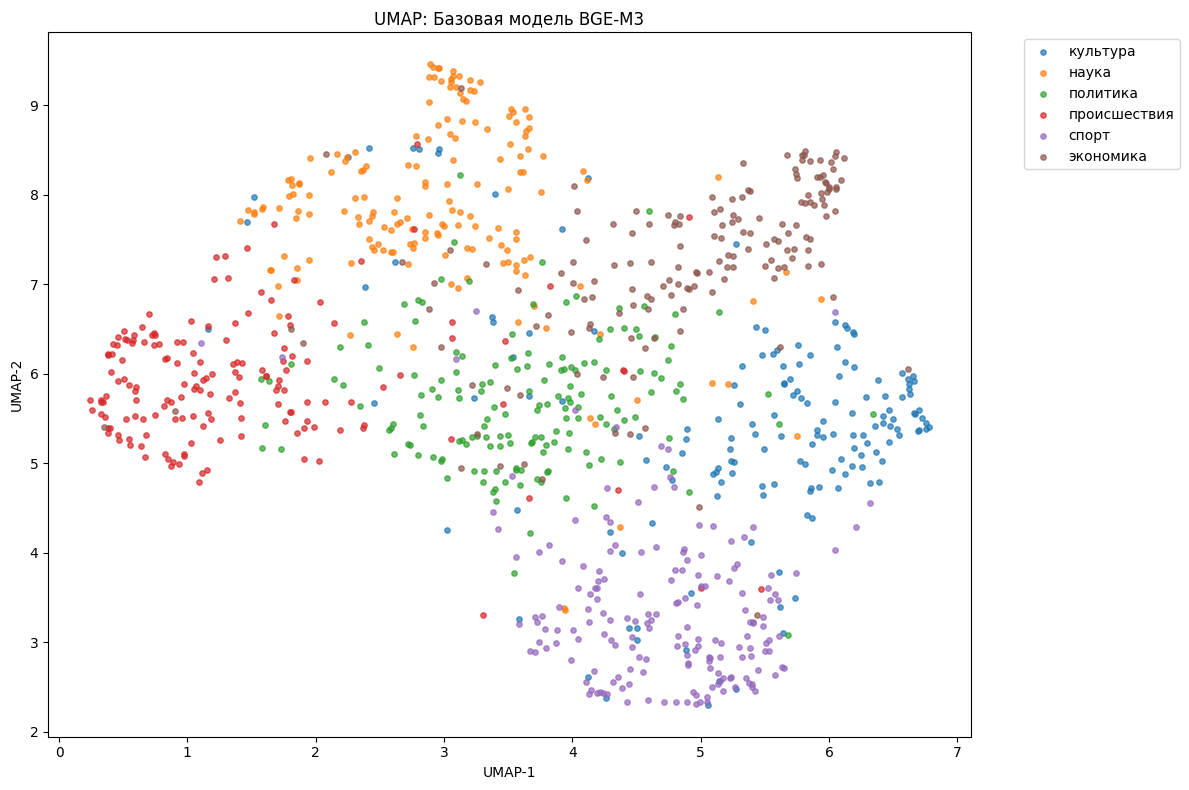

In [3]:
model_name = "BAAI/bge-m3"
base_model = SentenceTransformer(model_name)

# Загрузка датасета для визуализации
vis_dataset = load_dataset("ai-forever/headline-classification", split="test[:1000]")
vis_texts = vis_dataset["text"]
vis_labels = vis_dataset["label_text"]

# Ваш код здесь: получение эмбеддингов базовой моделью
base_embeddings = base_model.encode(vis_texts, batch_size=32, show_progress_bar=True,convert_to_numpy=True)

def plot_embeddings(embeddings, labels, title):

    reducer = umap.UMAP(
        n_components=2,
        random_state=SEED
    )

    embeddings_2d = reducer.fit_transform(
        embeddings
    )

    plt.figure(figsize=(12, 8))

    unique_labels = sorted(
        set(labels)
    )

    for label in unique_labels:

        mask = np.array(labels) == label

        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            s=15,
            alpha=0.7,
            label=label
        )

    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

plot_embeddings(base_embeddings, vis_labels, "UMAP: Базовая модель BGE-M3")

## Часть 2. Оценка базового качества поиска (25 баллов)

Замерим метрики семантического поиска до квантизации.

**Задание:**
1. Загрузите датасет `ai-forever/rubq-retrieval`. Этот датасет состоит из трех отдельных подмножеств, которые нужно загрузить отдельно:
   * Вопросы: подмножество (config) `queries`, сплит `queries`. Содержит колонки `_id` (строка) и `text` (строка).
   * База знаний: подмножество (config) `corpus`, сплит `corpus`. Содержит колонки `_id` (строка), `title` (строка) и `text` (строка).
   * Разметка релевантности (qrels): подмножество (config) `default`, сплит `test`. Содержит колонки `query-id` (строка), `corpus-id` (строка) и `score` (число).
2. Напишите функцию `evaluate_retrieval`, которая принимает на вход модель, вопросы (`queries`), базу знаний (`corpus`) и разметку релевантности (`qrels`), и возвращает метрики Recall@5 и Recall@10.
3. Для ускорения поиска реализуйте индекс на основе `faiss.IndexFlatIP`.
4. Замерьте и зафиксируйте базовое качество поиска.

**Подсказки и рекомендации по оценке:**
* Поскольку мы используем `faiss.IndexFlatIP` (поиск по скалярному произведению), векторы перед добавлением в индекс необходимо L2-нормализовать. Укажите `normalize_embeddings=True` при вызове метода `encode`.
* **Как считать Recall@K:**
  1. Для каждого вопроса (колонка `text` из `queries`) получите топ-K ближайших документов из базы знаний (колонка `text` из `corpus`) с помощью `faiss.Index.search`.
  2. Для этого же вопроса найдите все правильные (релевантные) документы в таблице `qrels` (строки, где колонка `query-id` совпадает с `_id` вопроса, а колонка `corpus-id` содержит ID правильных документов). Обратите внимание: у многих вопросов правильных документов несколько.
  3. Вычислите Recall@K для текущего вопроса по формуле: (количество правильных документов, попавших в ваш топ-K) / (общее количество правильных документов для этого вопроса из `qrels`).
  4. Итоговый Recall@K - это среднее арифметическое значений Recall@K по всем вопросам.
* **Маппинг идентификаторов:** Метод `faiss.Index.search` возвращает целочисленные индексы строк (от 0 до N-1). Однако в таблице `qrels` в колонке `corpus-id` лежат строковые ID документов. Важно: эти строковые ID из колонки `_id` корпуса не совпадают с порядковыми номерами строк (в нумерации есть пропуски). Поэтому простое преобразование `str(faiss_index)` даст неверные результаты. Обязательно постройте словарь-маппинг: `id_map = {i: doc_id for i, doc_id in enumerate(corpus['_id'])}` и используйте его для перевода индексов FAISS в строковые `corpus-id`.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

In [4]:
# Загрузка датасета для оценки
eval_queries = load_dataset("ai-forever/rubq-retrieval", "queries", split="queries")
eval_corpus = load_dataset("ai-forever/rubq-retrieval", "corpus", split="corpus")
eval_qrels = load_dataset("ai-forever/rubq-retrieval", "default", split="test")

def evaluate_retrieval(model, queries_ds, corpus_ds, qrels_ds, top_k=[5, 10]):
    # Подсказка:
    # 1. Закодировать corpus_ds["text"] (normalize_embeddings=True)

    corpus_embeddings = model.encode(
        corpus_ds["text"],
        batch_size=32,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True
    )

    # 2. Создать faiss.IndexFlatIP(dimension) и добавить векторы корпуса

    dimension = corpus_embeddings.shape[1]

    index = faiss.IndexFlatIP(dimension)

    index.add(corpus_embeddings)

    # 3. Закодировать queries_ds["text"] (normalize_embeddings=True)

    query_embeddings = model.encode(
        queries_ds["text"],
        batch_size=32,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True
    )

    # 4. Сделать index.search(query_embeddings, max(top_k))

    max_k = max(top_k)

    scores, indices = index.search(
        query_embeddings,
        max_k
    )

    # 5. Перевести индексы FAISS в строковые corpus-id через id_map (см. подсказку выше)

    id_map = {
        i: doc_id
        for i, doc_id in enumerate(corpus_ds["_id"])
    }

    qrels_dict = {}

    for row in qrels_ds:

        query_id = row["query-id"]
        corpus_id = row["corpus-id"]

        if query_id not in qrels_dict:
            qrels_dict[query_id] = set()

        qrels_dict[query_id].add(corpus_id)

    # 6. Рассчитать Recall@K: среднее по вопросам от (найдено релевантных в топ-K / всего релевантных)

    metrics = {}

    for k in top_k:

        recalls = []

        for idx, query_id in enumerate(queries_ds["_id"]):

            relevant_docs = qrels_dict.get(query_id, set())

            if len(relevant_docs) == 0:
                continue

            retrieved_docs = [
                id_map[i]
                for i in indices[idx][:k]
            ]

            found = len(
                set(retrieved_docs) & relevant_docs
            )

            recall = found / len(relevant_docs)

            recalls.append(recall)

        metrics[f"Recall@{k}"] = np.mean(recalls)

    return metrics


base_metrics = evaluate_retrieval(base_model, eval_queries, eval_corpus, eval_qrels)
print("Базовые метрики BGE-M3:", base_metrics)

README.md:   0%|          | 0.00/367 [00:00<?, ?B/s]

queries.jsonl:   0%|          | 0.00/188k [00:00<?, ?B/s]

Generating queries split:   0%|          | 0/1692 [00:00<?, ? examples/s]

data/corpus.jsonl.zip: reconstructing file:   0%|          |  0.00B / 13.7MB            

data/corpus.jsonl.zip: downloading bytes:           |  0.00B            

...

test.jsonl:   0%|          | 0.00/155k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2845 [00:00<?, ? examples/s]

Batches:   0%|          | 0/1776 [00:00<?, ?it/s]

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Базовые метрики BGE-M3: {'Recall@5': np.float64(0.7552122030845434), 'Recall@10': np.float64(0.8395178993583249)}


## Часть 3. Квантизация модели (30 баллов)

Теперь применим динамическую квантизацию к модели. Это приведет веса линейных слоев к формату INT8.

**Задание:**
1. Сохраните базовую модель на диск, чтобы замерить ее размер.
2. Используйте `torch.quantization.quantize_dynamic` для квантизации линейных слоев модели.
3. Сохраните веса квантованной модели на диск через `torch.save(quantized_model.state_dict(), ...)`. Обратите внимание: стандартный метод `.save()` у квантованной модели не сработает, так как `safetensors` не умеет сериализовать INT8-тензоры.
4. Напишите функцию для замера времени инференса (получения эмбеддингов) на 1000 текстах из `vis_texts`.
5. Замерьте и сравните размер моделей (в МБ) и время инференса (в секундах) на CPU.
6. Опубликуйте модель на huggingface.

**Подсказки и рекомендации:**
* **Код квантизации:** `quantized_model = torch.quantization.quantize_dynamic(base_model, {torch.nn.Linear}, dtype=torch.qint8)`
* Важно: динамическая квантизация PyTorch имеет смысл только при запуске на CPU. Если вы используете GPU, перенесите модель на CPU перед квантизацией и замерами времени: `base_model.to('cpu')`.
* Для замера размера директории с моделью можно использовать `os.path.getsize` в цикле по всем файлам.
* При замере времени инференса используйте `time.perf_counter()` и обязательно делайте "прогревочный" прогон (например, на 10 текстах) перед основными замерами, чтобы инициализировать кэши.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

In [5]:
# Переносим модель на CPU для корректных замеров квантизации
base_model.to('cpu')

# Сохраняем базовую модель для замера размера
base_model.save("bge_m3_base")

# Ваш код здесь: квантизация модели
quantized_model = torch.quantization.quantize_dynamic(
    base_model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

# Сохраняем квантованную модель
torch.save(quantized_model.state_dict(), "bge_m3_quantized.pt")

def get_dir_size(path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return total_size / (1024 * 1024) # в МБ

print(f"Размер базовой модели: {get_dir_size('bge_m3_base'):.2f} МБ")
print(f"Размер квантованной модели: {os.path.getsize('bge_m3_quantized.pt') / (1024 * 1024):.2f} МБ")

def measure_inference_time(model, texts):
    # Прогрев
    model.encode(texts[:10], show_progress_bar=False)

    # Замер
    start_time = time.perf_counter()
    # Ваш код здесь: получение эмбеддингов для texts

    model.encode(
        texts,
        batch_size=32,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    end_time = time.perf_counter()

    return end_time - start_time

base_time = measure_inference_time(base_model, vis_texts)
quant_time = measure_inference_time(quantized_model, vis_texts)
print(f"Время базовой модели: {base_time:.2f} сек")
print(f"Время квантованной модели: {quant_time:.2f} сек")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_1347/3881526493.py:8: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Размер базовой модели: 2182.18 МБ
Размер квантованной модели: 1299.08 МБ
Время базовой модели: 152.34 сек
Время квантованной модели: 118.83 сек


In [6]:
!pip install -q huggingface_hub

In [7]:
from google.colab import userdata
from huggingface_hub import login, create_repo, upload_file

login(token=userdata.get("HF_WRITE_TOKEN"))

repo_id = "yulivvv/bge-m3-quantized"

create_repo(
    repo_id=repo_id,
    exist_ok=True
)

upload_file(
    path_or_fileobj="bge_m3_quantized.pt",
    path_in_repo="bge_m3_quantized.pt",
    repo_id=repo_id
)

print("Модель успешно опубликована!")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/bge_m3_quantized.pt:   1%|1         | 16.0MB / 1.36GB            

No files have been modified since last commit. Skipping to prevent empty commit.


Модель успешно опубликована!


ссылка на модель на huggingface: https://huggingface.co/yulivvv/bge-m3-quantized

## Часть 4. Оценка качества после квантизации (25 баллов)

Проверим, насколько сильно просело качество поиска после сжатия модели до INT8.

**Задание:**
1. Снова вызовите функцию `evaluate_retrieval` на датасете `ai-forever/rubq-retrieval`, но теперь передайте в неё квантованную модель.
2. Сравните метрики Recall@K до и после квантизации.
3. Повторите процесс из Части 1: визуализируйте эмбеддинги датасета `ai-forever/headline-classification` с помощью квантованной модели. Сравните два графика.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

In [5]:
import gc

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
# @title
# Ваш код здесь: оценка Recall@K для квантованной модели

quant_metrics = evaluate_retrieval(quantized_model, eval_queries, eval_corpus, eval_qrels)
print("Метрики после квантизации:", quant_metrics)

In [ ]:
# Ваш код здесь: получение эмбеддингов квантованной моделью и визуализация
quantized_embeddings = quantized_model.encode(
    vis_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

plot_embeddings(
    quantized_embeddings,
    vis_labels,
    "UMAP: Квантованная модель BGE-M3"
)
# plot_embeddings(quantized_embeddings, vis_labels, "UMAP: Квантованная модель BGE-M3")

### Выводы

Напишите краткий вывод по результатам эксперимента. Насколько уменьшился размер модели? Насколько ускорился инференс? Насколько сильно упали метрики Recall@K? Оправдан ли такой компромисс для продакшена?

**Ваш ответ:**

В результате динамической квантизации размер модели уменьшился с 2182.18 МБ до 1299.08 МБ, что составляет примерно 40%. Время инференса на CPU также сократилось: с 152.34 сек до 118.83 сек, то есть примерно на 22%. Базовая модель показала качество поиска Recall@5 = 0.7552 и Recall@10 = 0.8395. Из-за ограничений оперативной памяти среды Google Colab повторно оценить метрики Recall@K после квантизации не удалось. Тем не менее полученные результаты демонстрируют, что квантизация позволяет существенно уменьшить размер модели и ускорить инференс. Для продакшен-сценариев, где критичны скорость работы и экономия памяти, такой компромисс можно считать оправданным, особенно при использовании модели на CPU.